In [177]:
import pandas as pd
import geopandas as gpd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt
import rasterio

pd.set_option('display.max_columns', None)  # mostra todas as colunas
pd.set_option('display.max_rows', None)     # (opcional) mostra todas as linhas
pd.set_option('display.max_colwidth', None) # mostra conteúdo completo das células

In [178]:
train_data_path = "train_data/train_data.shp"
test_data_path = "test_data/test_data.shp"
test_answer_data_path = "test_answer_data/test_answer_data.shp"

In [179]:
train_data = gpd.read_file(train_data_path)
test_data = gpd.read_file(test_data_path)
test_answer_data = gpd.read_file(test_answer_data_path)

train_data = train_data.drop(columns=['soma_indic'], axis=1)
train_data = train_data.rename(columns={'cls': 'queimada'})

In [180]:
# 3. Calcular melhor número de clusters com método do cotovelo (elbow method)
from math import sqrt

def optimal_number_of_clusters(wcss, k_min=1):
    x1, y1 = k_min, wcss[0]
    x2, y2 = k_min + len(wcss) - 1, wcss[-1]

    distances = []
    for i in range(len(wcss)):
        x0 = k_min + i
        y0 = wcss[i]
        numerator = abs((y2 - y1) * x0 - (x2 - x1) * y0 + x2*y1 - y2*x1)
        denominator = sqrt((y2 - y1)**2 + (x2 - x1)**2)
        distances.append(numerator / denominator)

    optimal_k = distances.index(max(distances)) + k_min
    return optimal_k


X = test_data[["dnbr_1", "dnbrswir_1", "dndvi_1"]].copy()
wss = []
K = range(1, 11) #stop -1
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42,n_init="auto")
    kmeans.fit(X)
    wss.append(kmeans.inertia_) # Armazena o WSS (inertia) para cada k

Melhor quantidade de clusters calculada: 2


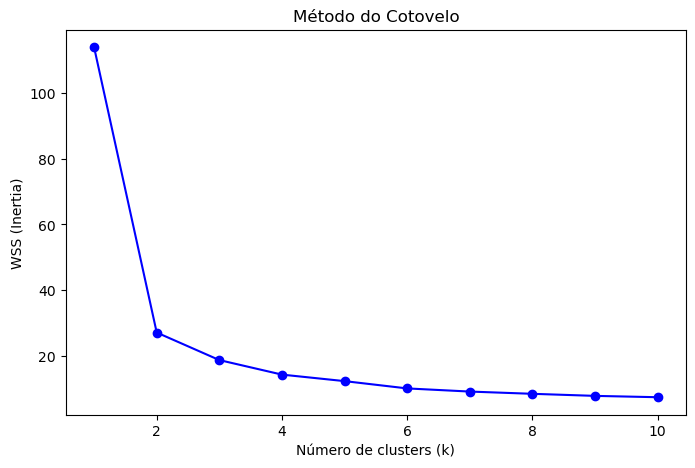

In [181]:
clusters_pontos = optimal_number_of_clusters(wss, k_min=1)

print(f"Melhor quantidade de clusters calculada: {clusters_pontos}")

plt.figure(figsize=(8,5))
plt.plot(K, wss, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('WSS (Inertia)')
plt.title('Método do Cotovelo')
plt.show()

In [182]:
kmeans = KMeans(n_clusters=clusters_pontos, random_state=1, n_init="auto")

clusters = kmeans.fit_predict(X)


test_data["Cluster"] = clusters
test_data["Cluster"] = test_data["Cluster"].astype("category")

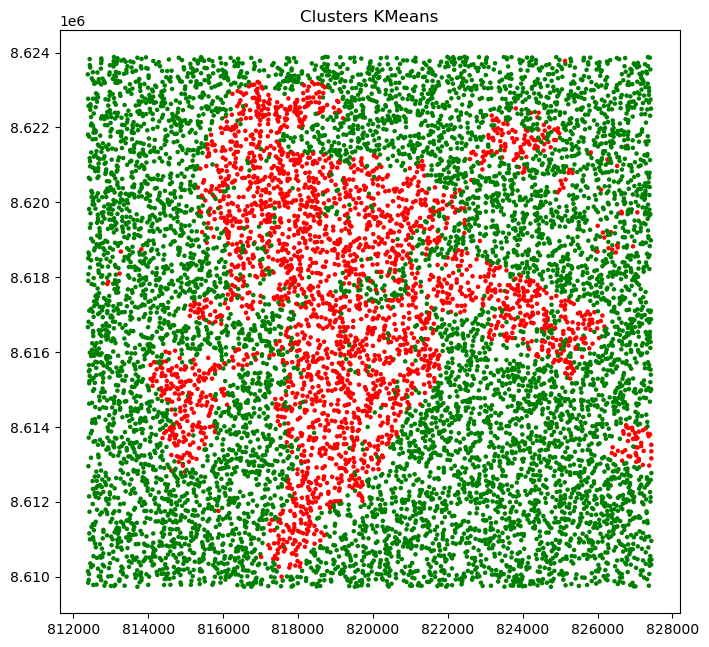

In [184]:
cores = {
    0: "red",
    1: "green",
    2: "orange",
    3: "yellow",
    4: "purple",
    5: "black",
    6: "pink",
}

test_data["cor"] = test_data["Cluster"].map(cores)

fig, ax = plt.subplots(figsize=(8, 8))

test_data.plot(
    color=test_data["cor"],
    markersize=5,
    ax=ax
)

plt.title("Clusters KMeans")
plt.show()

In [185]:
# Nível 2, k-means a partir dos valores obtidos nas imagens .tif

In [186]:
with rasterio.open("imagens_dif/nbr_dif.tif") as src1:
    band1 = src1.read(1)

with rasterio.open("imagens_dif/nbrswir_dif.tif") as src2:
    band2= src2.read(1)

with rasterio.open("imagens_dif/ndvi_dif.tif") as src3:
    band3 = src3.read(1)

In [187]:
dnbr = band1.flatten()
dnbrswir = band2.flatten()
dndvi = band3.flatten()

In [188]:
mask = (
    (dnbr != -9999) &
    (dnbrswir != -9999) &
    (dndvi != -9999)
)

X = pd.DataFrame({
    "dnbr": dnbr[mask],
    "dnbrswir": dnbrswir[mask],
    "dndvi": dndvi[mask]
})

In [239]:
n_clusters = 8

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")

clusters = kmeans.fit_predict(X)

In [240]:
cluster_img = np.full(dnbr.shape, -1)  # cria matriz vazia

cluster_img[mask] = clusters
cluster_img = cluster_img.reshape(band1.shape)

In [241]:
with rasterio.open(
    f"output/clusters_{n_clusters}.tif",
    "w",
    driver="GTiff",
    height=cluster_img.shape[0],
    width=cluster_img.shape[1],
    count=1,
    dtype=cluster_img.dtype,
    crs=src1.crs,
    transform=src1.transform,
) as dst:
    dst.write(cluster_img, 1)

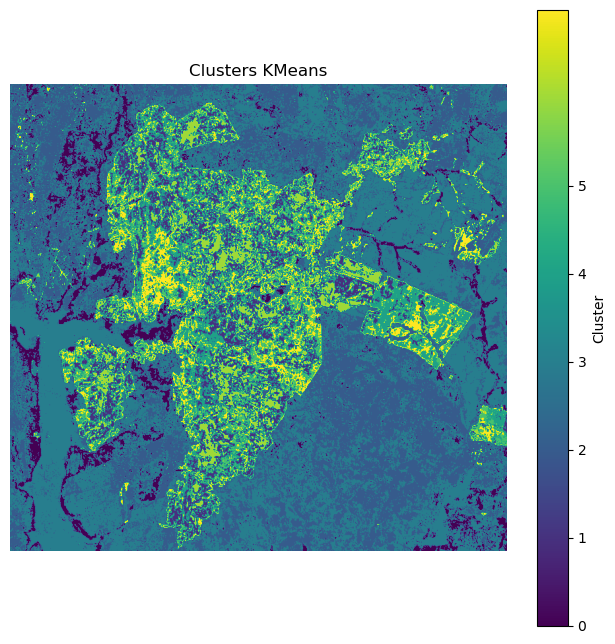

In [242]:
plt.figure(figsize=(8, 8))
plt.imshow(cluster_img)
plt.colorbar(ticks=range(6), label="Cluster")
plt.title("Clusters KMeans")
plt.axis("off")
plt.show()